In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [44]:
df = pd.read_csv('/content/Iris.csv')

In [45]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [46]:
df.shape

(150, 6)

In [47]:
df.loc[:50]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [48]:
df.loc[50:100]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
51,52,6.4,3.2,4.5,1.5,Iris-versicolor
52,53,6.9,3.1,4.9,1.5,Iris-versicolor
53,54,5.5,2.3,4.0,1.3,Iris-versicolor
54,55,6.5,2.8,4.6,1.5,Iris-versicolor
55,56,5.7,2.8,4.5,1.3,Iris-versicolor
56,57,6.3,3.3,4.7,1.6,Iris-versicolor
57,58,4.9,2.4,3.3,1.0,Iris-versicolor
58,59,6.6,2.9,4.6,1.3,Iris-versicolor
59,60,5.2,2.7,3.9,1.4,Iris-versicolor


In [49]:
df.loc[100:150]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
100,101,6.3,3.3,6.0,2.5,Iris-virginica
101,102,5.8,2.7,5.1,1.9,Iris-virginica
102,103,7.1,3.0,5.9,2.1,Iris-virginica
103,104,6.3,2.9,5.6,1.8,Iris-virginica
104,105,6.5,3.0,5.8,2.2,Iris-virginica
105,106,7.6,3.0,6.6,2.1,Iris-virginica
106,107,4.9,2.5,4.5,1.7,Iris-virginica
107,108,7.3,2.9,6.3,1.8,Iris-virginica
108,109,6.7,2.5,5.8,1.8,Iris-virginica
109,110,7.2,3.6,6.1,2.5,Iris-virginica


In [50]:
df.loc[[44,88,111]]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
44,45,5.1,3.8,1.9,0.4,Iris-setosa
88,89,5.6,3.0,4.1,1.3,Iris-versicolor
111,112,6.4,2.7,5.3,1.9,Iris-virginica


In [51]:
df.dtypes

,0
Id,int64
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64
Species,object


In [52]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [53]:
df.drop(columns=['Id'], inplace=True)

In [54]:
le = LabelEncoder()

In [55]:
df['Species'] = le.fit_transform(df['Species'])

In [56]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [57]:
df.loc[[44,88,111]]

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
44,5.1,3.8,1.9,0.4,0
88,5.6,3.0,4.1,1.3,1
111,6.4,2.7,5.3,1.9,2


In [58]:
X = df.drop(columns=['Species'])  # independent variables

In [59]:
Y = df['Species']  # dependent variable (0, 1, 2)

In [60]:
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [61]:
Y.head()

,Species
0,0
1,0
2,0
3,0
4,0


In [62]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [63]:
print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

Training samples: (120, 4)
Testing samples : (30, 4)


In [64]:
scaler = StandardScaler()

In [65]:
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [66]:
model = KNeighborsClassifier(n_neighbors=5)

In [67]:
model.fit(X_train, Y_train)

KNeighborsClassifier()

In [68]:
Y_pred = model.predict(X_test)

In [69]:
sample = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)
sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)
print("Predicted class:", prediction)

Predicted class: [0]


In [70]:
accuracy  = accuracy_score(Y_test, Y_pred)              # overall correct predictions
precision = precision_score(Y_test, Y_pred, average='weighted')  # correctness per class, weighted by class size
recall    = recall_score(Y_test, Y_pred, average='weighted')     # how many actual cases were caught, weighted
f1        = f1_score(Y_test, Y_pred, average='weighted')         # balance of precision and recall

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


In [71]:
cm = confusion_matrix(Y_test, Y_pred)

In [72]:
cm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

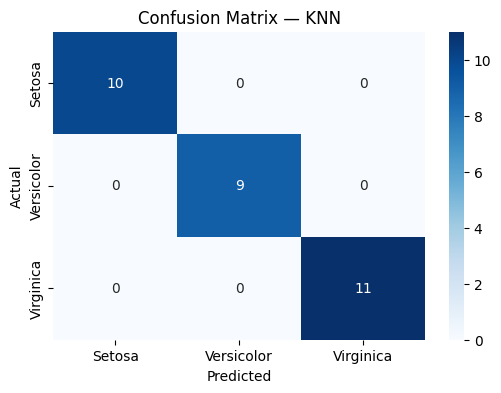

In [73]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.title('Confusion Matrix — KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()